# AP 155 Lab Exercise
---
## Exercise 3: Numbers in Computers II

_Instructions_: 
- **Output 1: Horner's Rule**. Create a solver of polynomial equations by direct evaluation and by Horner's rule. Create a figure comparing execution times, and deviations in result.
- **Output 2: Horner's Rule for Taylor Series**. Apply Horner's rule to create special functions without importing libraries. Create figures plotting these functions.

### Student Information
- _Full Name (Last Name, First Name)_: Abellana, Karl Gian
- _Student No._: 2024-09545
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1

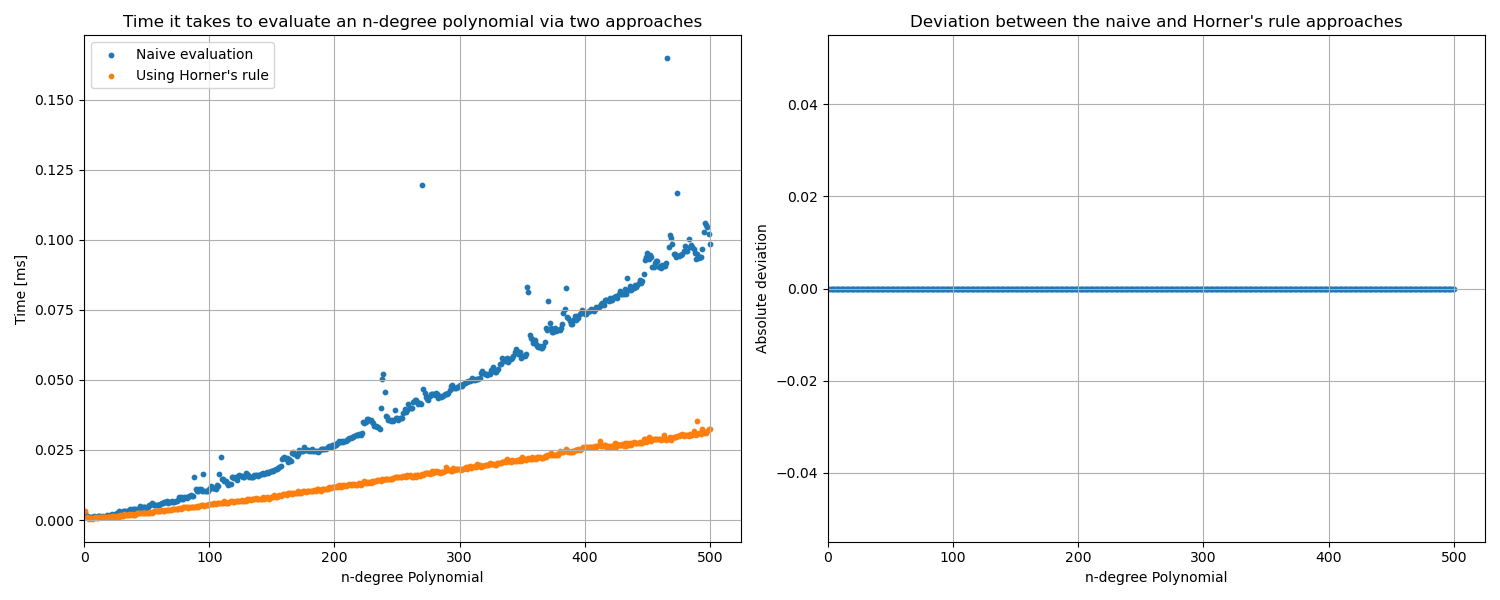
Figure 1

Figure 1 (left) compares the time it takes to evaluate an n-degree polynomial for $n \in [1,500]$ using coefficients of 1 for all terms and at $x=2$. From here we can see that the exection speed difference gets more apparent as n increases, with the evaluation using Horner's rule being more efficient in time than the naive evaluation. This is because Horner's rule removes the need for exponentiating x to the n-th degree per term. In figure 1 (right), the absolute deviation was also tested with the same setup with no deviation because of the values; coefficients of 1 and evaluating x to the n-th power at $x=2$ is simple in binary since its just 1 followed by n-zeros.

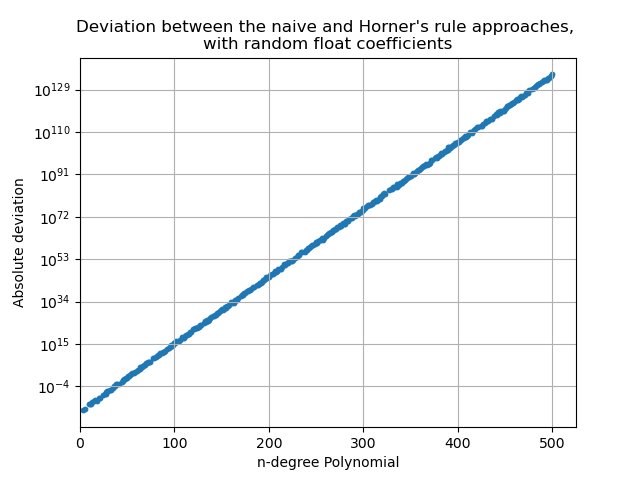

Figure 2

Figure 2 explores deviation between the two evaluations, with a random set of float coefficients. This time, the deviation can be seen since we're operating with floats, which is highly susceptible to rounding errors which is proportional to the magnitude of the factors. Horner's rule minimizes this by minimizing the amount of multiplications in the algorithm. This also explains why there is a deviation for evaluating the polynomial with ```coeffs = [(-11)**i for i in reversed(range(8))]``` at ```x = 11.01```.

### Problem 2
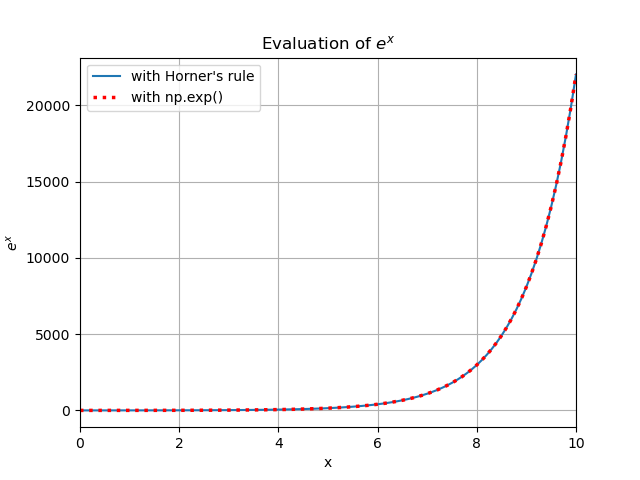
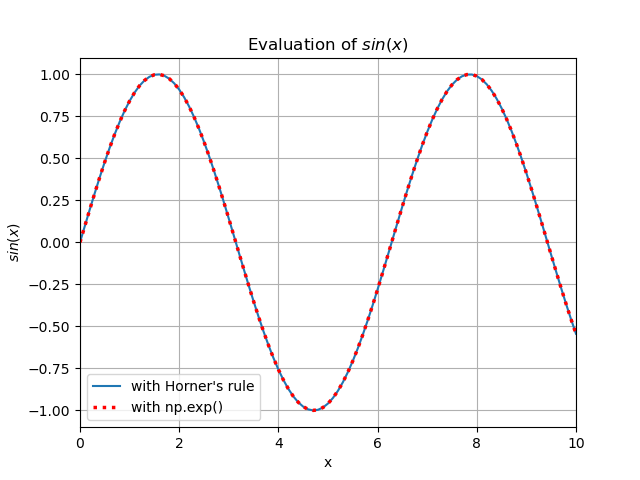

Figure 3 (left) and Figure 4 (right)

$e^x$ and $sin(x)$ can be approximated by using their Taylor series expansions. However, it experiences a similar problem to the polynomial evaluation from Problem 1, evaluating term-by-term is too costly. Thus, we employ Horner's rule to evaluate it more efficiently, the following are the factored versions of the expansions of $e^x$ and $sin(x)$, which were shown in section 2.

$$
\begin{aligned}
    e^x &= 1 + \frac{x}{1} \left(1 + \frac {x}{2} \left(1 + \frac{x}{3} \cdots \left(1 + \frac{x}{n} \right)\right)\right) \\
    sin(x) &= x\left(1-\frac{x^2}{2\cdot3}\left(1-\frac{x^2}{4\cdot5}\cdots\left(1-\frac{x^2}{(2n)(2n+1)}\right)\right)\right)
\end{aligned}
$$

We observe in their respective figures, we compare the values from the approximation via Taylor expansion with Horner's rule and ```np.exp()``` and ```np.sin()```, and visually the approximation function of $e^x$ and $sin(x)$ follows ```np.exp()```and ```np.sin()``` respectively.

### Other comments
- new favorite operator: ```:=```

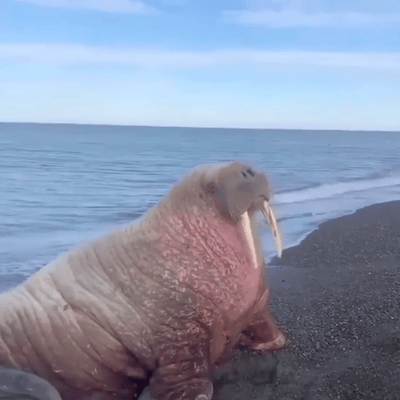


---
## Section 2: Code

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)

This problem discusses error buildup when trying to evaluate polynomials without and with the use of *Horner's rule*. Take a polynomial of degree $n - 1$:

$$P(x) = p_0 + p_1 x + p_2 x^2 + p_3 x^3 + \dots + p_{n-1} x^{n-1} \tag{2.98}$$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e., from left to right like how you would normally do it. You are not allowed to import any library such as `numpy`.


In [1]:
# code here
coeffs = [6,7,6,7,6,7]

"""
We define a function that takes in coefficients and assumes that each coefficient corresponds to a term with x to the nth degree starting from the left
So, n = length of coeffs array.
We can use list comprehension to evaluate each term with their corresponding coefficients. We iterate over range(n) instead of the elements
because we want to get the index number which is the exponent of x.
Using this sum() function we can return the sum of all the evaluated terms.
"""
def evalPolynomialNaive(coeffs, x):
    n = len(coeffs)
    return sum([coeffs[i]*(x**i) for i in range(n)])


evalPolynomialNaive(coeffs, 2)

420

Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x \times x \times \dots \times x$ (where there are $i - 1$ multiplications). Thus, this way of approaching the problem corresponds to:

$$1 + 2 + \dots + n - 2 = \frac{(n - 1)(n - 2)}{2} \tag{2.99}$$

multiplications, from $x^2$ all the way up to $x^{n-1}$. If we rewrite the polynomial:

$$P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + \dots + x(p_{n-2} + xp_{n-1})\dots))) \tag{2.100}$$

then we can get away with only $n - 1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree). 

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the new way, i.e., from right to left. You are not allowed to import any library such as `numpy`. Apply the previous two functions to the (admittedly artificial) case of:

`coeffs = [(-11)**i for i in reversed(range(8))]`  
and `x = 11.01`. Observe any discrepancy and discuss its origin.

In [2]:
#code here
coeffs = [(-11)**i for i in reversed(range(8))]
x = 11.01

"""
Solving the polynomial using Horner's rule requires us to work from the inside out.
Meaning, the next iterations will depend on the previous iteration, we have to initialize an accumulator variable.
Luckily, accumulator variables can still be used in list comprehension using the walrus operator ":=".
The list comprehension below essentially functions like:

term = 0
for i in reversed(coeffs):
    term  = i+term*x
return term
"""


def evalPolynomialHorner(coeffs,x):
    term = 0
    # we can now iterate over the actual element since we don't need to exponentiate x anymore.
    iterator = [term := i+term*x for i in reversed(coeffs)] # walrus operator ':=' allows list comp to use an "outisde" accumulator variable
    return term
    
print(f"Naive evaluation of P(x): {evalPolynomialNaive(coeffs, x)}")
print(f"Horner's rule evaluation of P(x): {evalPolynomialHorner(coeffs, x)}")

Naive evaluation of P(x): 71056.02362162992
Horner's rule evaluation of P(x): 71056.02362163365


Extend your work by testing both functions over increasing polynomial degrees $n \in [1, 500]$ evaluated at $x=2$. Measure execution times with the `time` library and track the absolute deviation $|P_{\text{naive}}(x) - P_{\text{Horner}}(x)|$. Plot the results side by side with `matplotlib` or `seaborn`.

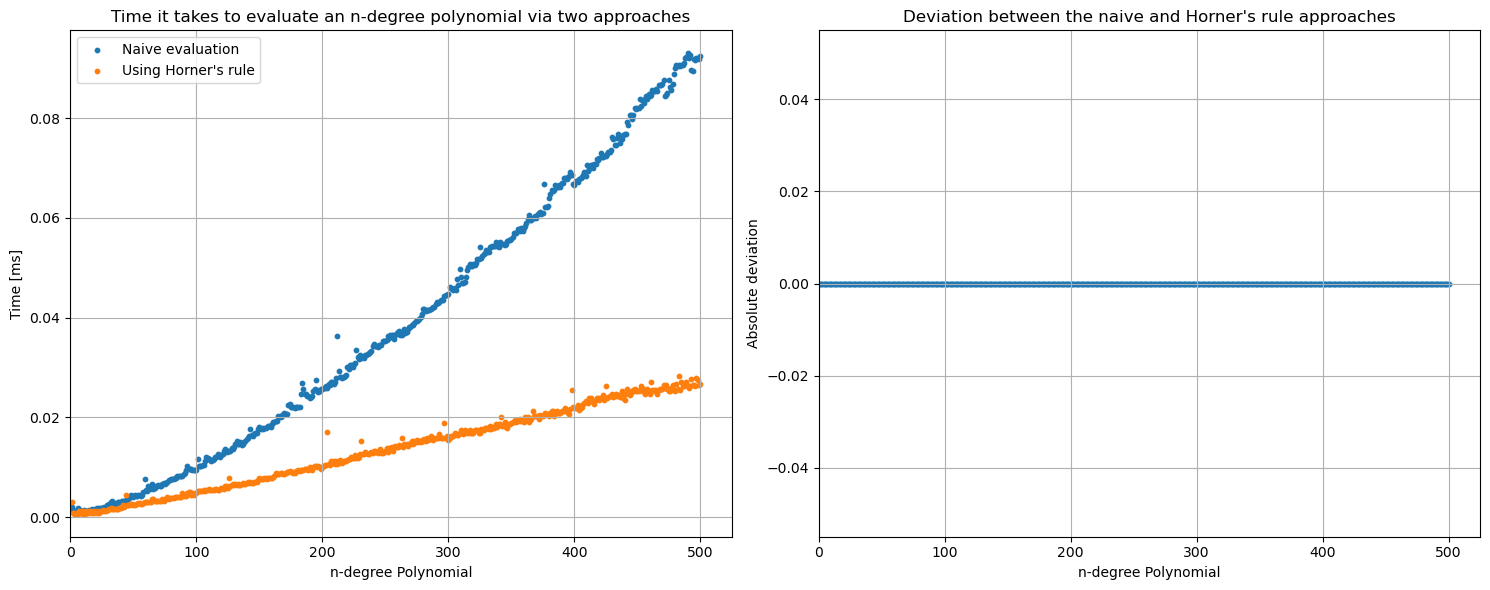

In [3]:
# code here
import time
import matplotlib.pyplot as plt
x = 2
n = 500

# solving naively
ts_naive = []
naive_eval = []

for i in range(n):

    # choose a convenient 1 for all coefficients
    # note range i+1 so that 0th degree alone is skipped: [1,500]th degrees only
    coeffs = [1 for j in range(i+1)]
    
    # we get the time before running the function and after running, getting the difference should give us
    # how long the function took to run.
    start_time = time.time()
    val_naive = evalPolynomialNaive(coeffs, x)
    end_time = time.time()

    # here we separate the appends so that it won't interfere with the time measuring
    ts_naive.append((end_time-start_time)*1000) # turn seconds to milliseconds
    naive_eval.append(val_naive)

# solving using Horner's rule
ts_horner = []
horner_eval = []
for i in range(n):
    coeffs = [1 for j in range(i+1)]
    start_time = time.time()
    val_horner = evalPolynomialHorner(coeffs, x)
    end_time = time.time()

    # same thing, separate the appends so that it won't interfere with time measuring
    ts_horner.append((end_time-start_time)*1000) # turn seconds to milliseconds
    horner_eval.append(val_horner)

# getting the absolute deviation
abs_deviation = [abs(i-j) for i,j in zip(naive_eval, horner_eval)]


# plot init
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ns = [i+1 for i in range(500)] #[1,500]


# naive vs horner time eval 
ax1.scatter(ns, ts_naive, label = "Naive evaluation", s=10)
ax1.scatter(ns, ts_horner, label = "Using Horner's rule", s=10)
ax1.set_xlim(left=0)
ax1.set_title("Time it takes to evaluate an n-degree polynomial via two approaches")
ax1.set_xlabel("n-degree Polynomial")
ax1.set_ylabel("Time [ms]")
ax1.grid(True)
ax1.legend()

# abs dev between naive and horner
ax2.scatter(ns, abs_deviation, s=10)
ax2.set_xlim(left = 0)
ax2.set_title("Deviation between the naive and Horner's rule approaches")
ax2.set_xlabel("n-degree Polynomial")
ax2.set_ylabel("Absolute deviation")
ax2.grid(True)
plt.tight_layout()
plt.savefig("Problem 1 Fig 1.png")
plt.show()


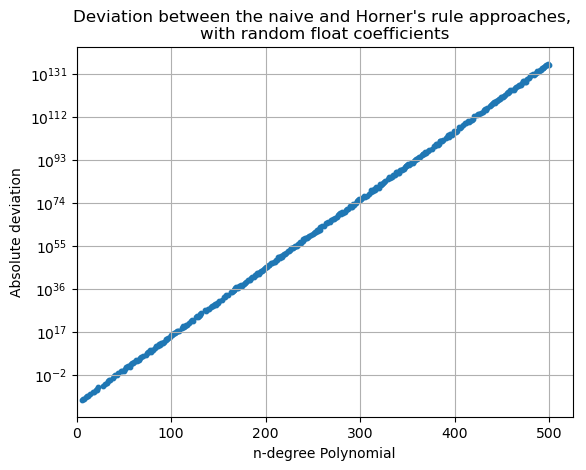

In [4]:
# lets try a different set of coefficients to show error deviation
import random

# consts
x = 2
n = 500

# random float function between 0.0 and 10.0
def randomFloat():
    return(random.uniform(0.0, 10.0))


# solving naively and using Horner's rule
naive_eval = []
horner_eval = []

# we go to n+1 because we want to include 500, index starts at 0
for i in range(n):
    
    # this time we choose an arbitrary float so that we can see how the error behaves for floats.
    # range i+1 so that 0th degree alone is skipped
    coeffs = [randomFloat() for j in range(i+1)]

    # we do both evals so that both of the functions will get the same coefficients, at least, on a single step.
    naive_eval.append(evalPolynomialNaive(coeffs, x))
    horner_eval.append(evalPolynomialHorner(coeffs, x))

# getting the absolute deviation
abs_deviation = [abs(i-j) for i,j in zip(naive_eval, horner_eval)]
ns = [i+1 for i in range(500)] #[1,500]

plt.scatter(ns, abs_deviation, s=10)
# do log scale because the data is exponential
plt.yscale("log")
plt.xlim(left = 0)
plt.title("Deviation between the naive and Horner's rule approaches, \nwith random float coefficients")
plt.xlabel("n-degree Polynomial")
plt.ylabel("Absolute deviation")
plt.grid(True)
plt.savefig("Problem 1 Fig 2.png")
plt.show()

#### Problem 1 code summary

Two functions were defined, making use of list comprehensions, for evalulating polynomial of n-degrees with arbitary coefficients, naively ```evalPolynomialNaive()```, and using Horner's rule ```evalPolynomialHorner()``` (iterated in reverse). These functions were tested for execution time via the ```time``` library and its ```time.time()``` function, and the absolute deviation between their values, evaluating them at $x=2$; with coefficients of 1 and with a random set of float coefficients from 0.0 to 10.0 generated by ```randomFloat()```.

Matplotlib was then used to plot the execution times and the absolute deviation of the two functions, the absolute deviation evaluated using a set of random floats were plotted with a log-y since the relation between deviation and n-degrees is exponential.

---

### Problem 2: Taylor Series Evaluation

By applying Horner's rule without using any libraries, create a function to evaluate $f(x) = e^x$ based on its Taylor series approximation. Plot for $x \in [0,10]$. Compare with `np.exp()`.

Using Horner's rule, we can evaluate $e^x$ this way,

$$
\begin{aligned}
    e^x &= \sum^{\infty}_{n=0}\frac{x^n}{n!} \\
    e^x &= 1 + \frac{x}{1!} + \frac{x^2}{2!} + \cdots + \frac{x^n}{n!} \\
    e^x &= 1 + \frac{x}{1} \left(1 + \frac {x}{2} + \frac{x^2}{2 \cdot 3}+\cdots + \frac{x^{n-1}}{2 \cdot 3 \cdot 4 \cdots n}\right) \\
    e^x &= 1 + \frac{x}{1} \left(1 + \frac {x}{2} \left(1+\frac{x}{3}+\cdots + \frac{x^{n-2}}{3 \cdot 4 \cdots n}\right)\right) \\
    e^x &= 1 + \frac{x}{1} \left(1 + \frac {x}{2} \left(1 + \frac{x}{3} \cdots \left(1 + \frac{x}{n} \right)\right)\right)
\end{aligned}
$$

Notice that the pattern is $1+\frac{x}{n}\cdot previous\;term$. Where the previous term for the innermost term is 1

value of e: 2.718281828459045


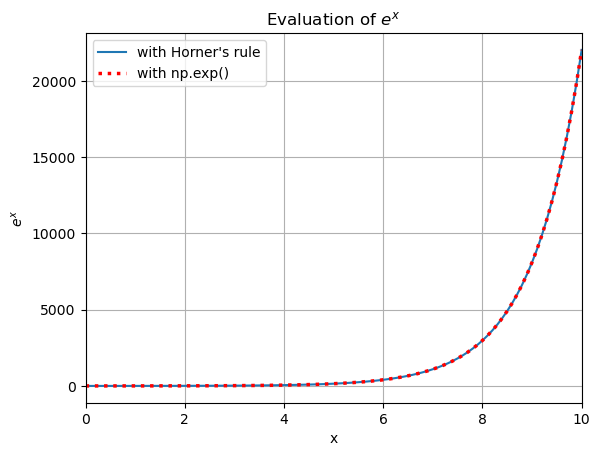

In [5]:
# code
import math
import matplotlib.pyplot as plt
import numpy as np

def ex(num_terms, x):
    # we're working backwards, so we start with the innermost term whose previous term is 1.
    # while this may be the previous term, it also works as an accumulator which gives us the answer.
    # we use the walrus operator again
    prev_term = 1
    # the pattern is 1+(x/n)(previous term) where n = i+1 since indexing ends at 0.
    iterator = [prev_term := 1 + (x/(i+1))*prev_term for i in reversed(range(num_terms))]
    return prev_term

# test by getting value of e
print(f"value of e: {ex(20, 1)}")


# plotting
xs = [i/10 for i in range(101)] # from 0 to 10 in steps of 0.1
fxs = [ex(100,i) for i in xs]
np_fxs = [np.exp(i) for i in xs] # compare with np.exp()

plt.plot(xs, fxs, label = "with Horner's rule")
plt.plot(xs, np_fxs, label = "with np.exp()", linestyle="dotted", color = "red", linewidth=2.5)
plt.xlim(left = 0, right = 10)
plt.legend(loc = "upper left")
plt.grid()
plt.xlabel("x")
plt.ylabel("$e^x$")
plt.title("Evaluation of $e^x$")
plt.savefig("e to the x.png")
plt.show()

Again, by applying Horner's rule without using any libraries, create function to evaluate $f(x) = \sin(x)$ using its Taylor series approximation. Can you avoid evaluating exponents completely? If not, how can you minimize these operations? Plot the result for $x \in [0,10]$. Compare with `np.sin()`.

Using Horner's rule, we can evaluate $sin(x)$ this way,

$$
\begin{aligned}
    sin(x) &= \sum^{\infty}_{n=0}(-1)^n\frac{x^{2n+1}}{(2n+1)!} \\
    sin(x) &= x-\frac{x^3}{3!}+\frac{x^5}{5!}-\cdots+(-1)^n\frac{x^2n+1}{(2n+1)!} \\
    sin(x) &= x\left(1-\frac{x^2}{3!}+\frac{x^4}{5!}-\cdots+(-1)^n\frac{x^2n}{(2n+2)!}\right) \\
    sin(x) &= x\left(1-\frac{x^2}{2\cdot3}\left(1-\frac{x^2}{4\cdot5}+\cdots-(-1)^n\frac{x^2n-4}{4\cdot5\cdots(2n+1)}\right)\right) \\
    sin(x) &= x\left(1-\frac{x^2}{2\cdot3}\left(1-\frac{x^2}{4\cdot5}\cdots\left(1-\frac{x^2}{(2n)(2n+1)}\right)\right)\right)
\end{aligned}
$$

Notice that the pattern here is $1-\frac{x^2}{(2n)(2n+1)} (previous\;term)$, but after the pattern terminates, x is multiplied to it all. This is done from the innermost until the outermost, while innermost's previous term is 1. We can't avoid exponentiation completely because the pattern for the next term's degree is +2, so the minimum operation degree of exponentiation is 2 for this one.

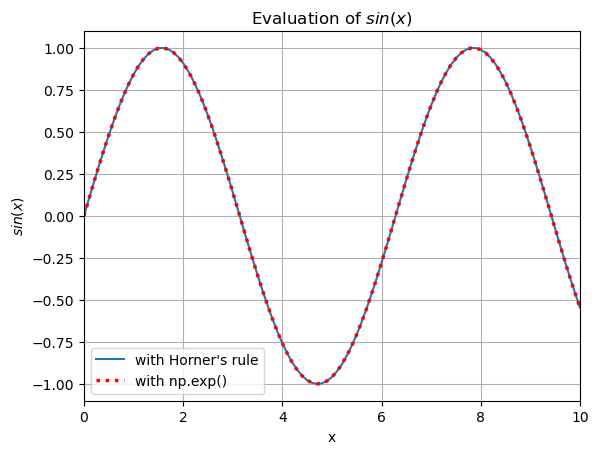

In [6]:
# code 

def sine(num_terms, x):
    # same idea with ex
    prev_term = 1
    # we shift i by 1 so that we include the last term.
    # the reason why we do this instead of range(num_term+1) is because this also excludes 0, which prevents division by 0 from happening
    # walrus operator!    ↓↓
    iterator = [prev_term := 1 - (x**2)/((2*(i+1))*(2*(i+1)+1)) * prev_term for i in reversed(range(num_terms))]
    return prev_term*x # multiply all by x after evaluating the pattern as seen above.

# plotting
xs = [i/10 for i in range(101)] # from 0 to 10 in steps of 0.1
gxs = [sine(100,i) for i in xs]
np_gxs = [np.sin(i) for i in xs]

plt.plot(xs, gxs, label = "with Horner's rule")
plt.plot(xs, np_gxs, label = "with np.exp()", linestyle="dotted", color = "red", linewidth=2.5)
plt.legend()
plt.grid()
plt.xlim(left = 0, right = 10)
plt.xlabel("x")
plt.ylabel("$sin(x)$")
plt.title("Evaluation of $sin(x)$")
plt.savefig("sinx.png")
plt.show()

#### Problem 2 code summary

Functions $e^x$ and $sin(x)$ were approximated using Taylor series with Horner's rule implemented, making use of list comprehensions iterated in reverse with the walrus operator. The functions were then compared with ```np.exp()``` and ```np.sin()``` respectively and plotted alongside each other using matplotlib.

---
## Section 3: Tutorials

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [8]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [9]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [10]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [11]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [12]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [13]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [14]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [15]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [16]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [17]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [18]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [19]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [20]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [21]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [22]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [23]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [24]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [25]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

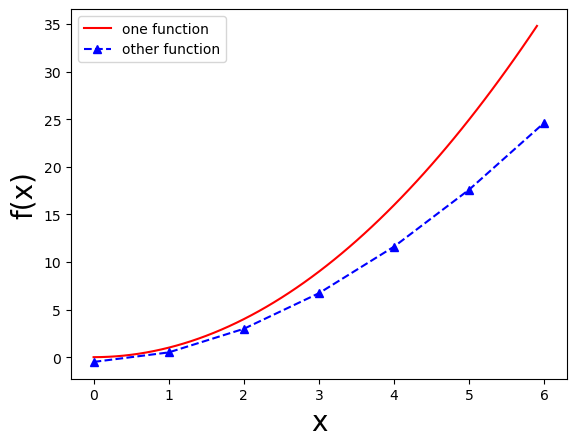

In [26]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

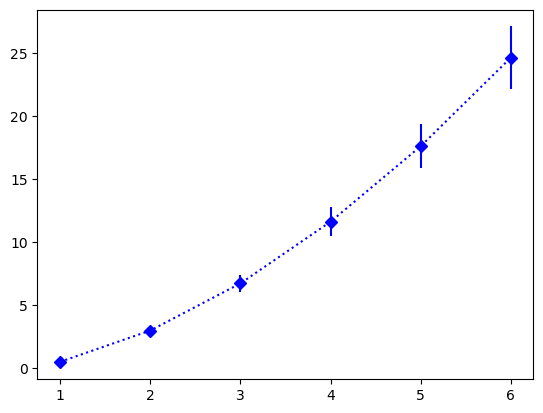

In [27]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [28]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [29]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])